# Neural ODE / Continious Normalizing on MNIST-Dataset

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchdiffeq import odeint_adjoint, odeint
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import re


# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Nb of Devices: ", torch.cuda.device_count())
    print("Device:",[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

2026-06-22 12:41:13.369057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782132073.569357      35 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782132073.632514      35 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782132074.142498      35 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782132074.142539      35 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782132074.142542      35 computation_placer.cc:177] computation placer alr

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Nb of Devices:  2
Device: ['Tesla T4', 'Tesla T4']
Compute capability: (7, 5)
Supported archs: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 1. Loading MNIST-Dataset

In [2]:
# download test and trainset of mnist via pytorchvision
def preprocess(x):
    return x * 2 - 1   

# define a transformation from PIL to tensor with normalized pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(preprocess)
])

# download mnist dataset
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# get images
images = (train_set.data.float() / 255.0) * 2 - 1

labels = train_set.targets

print()
print(train_set)
print()
print("shape images: ", images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 27.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 937kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.91MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.61MB/s]



Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Lambda()
           )

shape images:  torch.Size([60000, 28, 28])


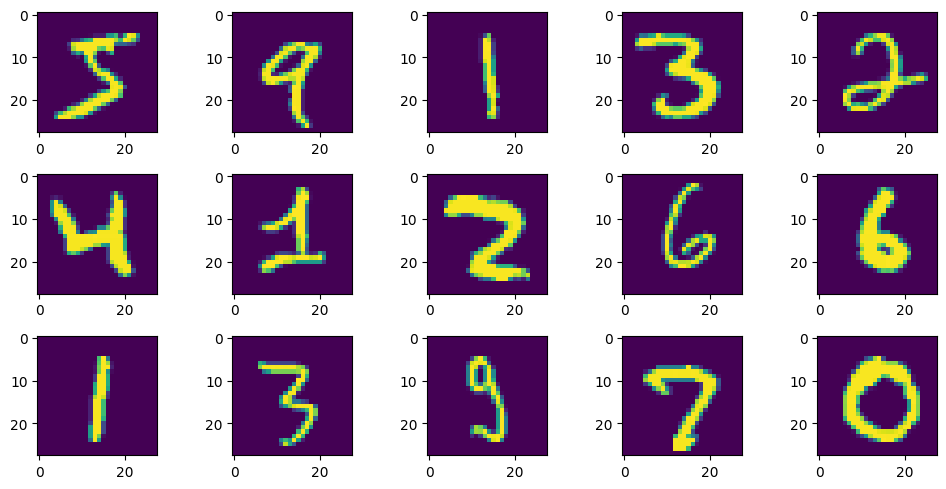

In [3]:
# plot example images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))
ax = ax.flatten()
for i in range(0, 60, 4):
    ax[int(i/4)].imshow(images[i])
fig.tight_layout()

In [4]:
# reduce multidimensional data distribution onto 2D plain with UMAP
reducer = UMAP(n_neighbors=5, n_components=2, min_dist=0.4, metric="euclidean")

# fit reducer onto data
X = images.reshape(len(train_set), -1)
reducer.fit(X)

# make embedding
embedding_train_set = reducer.transform(X).T

(2, 60000)


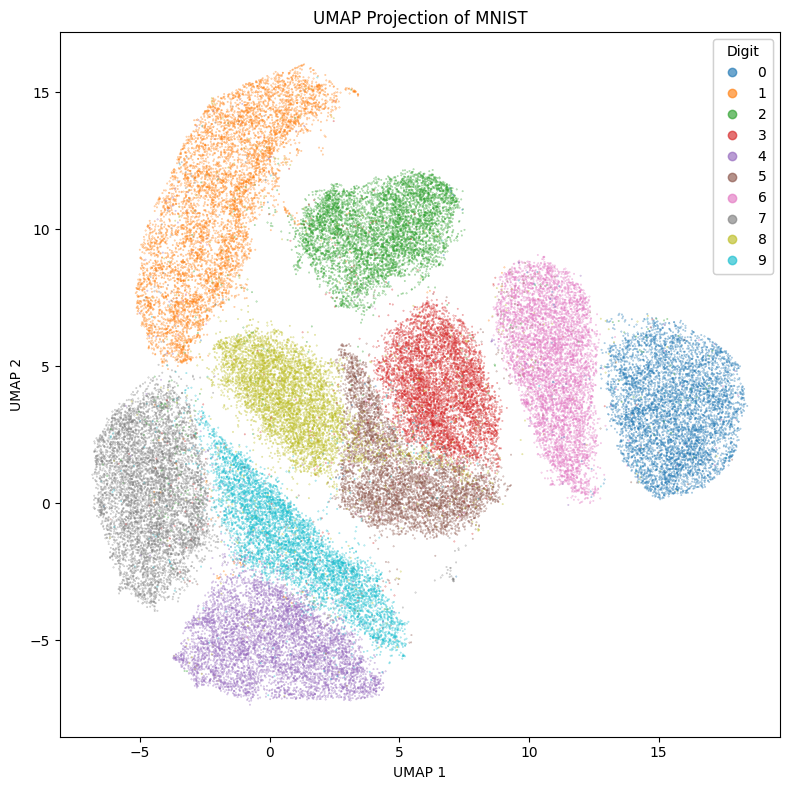

In [5]:
# plot embedding
print(embedding_train_set.shape)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(embedding_train_set[0], embedding_train_set[1], s=0.1, alpha=0.6, c=labels, cmap="tab10")
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="best")
ax.add_artist(legend)

ax.set_title("UMAP Projection of MNIST")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 2. Define Model

In [6]:
class SingleFlow(nn.Module):
    def __init__(self, input_channel):
        super().__init__()
        # Flow layers
        self.conv1 = nn.Conv2d(in_channels=input_channel+1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64+1, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64+1, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128+1, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.transconv1 = nn.ConvTranspose2d(in_channels=128+1, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.transconv2 = nn.ConvTranspose2d(in_channels=128+1, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.transconv3 = nn.ConvTranspose2d(in_channels=64+128+1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.transconv4 = nn.ConvTranspose2d(in_channels=64+1, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.out_conv = nn.Conv2d(in_channels=64+64+1, out_channels=input_channel, kernel_size=3, stride=1, padding=1)
        self.activation = nn.Softplus()

    def _tc(self, y, t):
        # concatenate t as extra channel
        return torch.cat([y, t.view(-1,1,1,1).expand(y.shape[0],1,y.shape[2],y.shape[3])], dim=1)

    def forward(self, t, y):
        # CNN
       # encoder
        e1 = self.activation(self.conv1(self._tc(y,  t)))   # 28x28, 64
        h  = self.activation(self.conv2(self._tc(e1, t)))   # 14x14, 64
        e3 = self.activation(self.conv3(self._tc(h,  t)))   # 14x14, 128
        h  = self.activation(self.conv4(self._tc(e3, t)))   #  7x7,  128
        # decoder
        h  = self.activation(self.transconv1(self._tc(h, t)))   #  7x7,  128
        h  = self.activation(self.transconv2(self._tc(h, t)))   # 14x14, 64
        h  = torch.cat([h, e3], dim=1)                          # skip @14: 64+128
        h  = self.activation(self.transconv3(self._tc(h, t)))   # 14x14, 64
        h  = self.activation(self.transconv4(self._tc(h, t)))   # 28x28, 64
        h  = torch.cat([h, e1], dim=1)                          # skip @28: 64+64
        h  = self.out_conv(self._tc(h, t))                      # 28x28, 1
        return h
    

class CNF(nn.Module):
    def __init__(self, channels=1):
        super().__init__()
        self.channels=channels

        # RNODE Net
        self.net = SingleFlow(self.channels)

    def forward(self, t, x_t):             
        # calculate divergence/trace
        with torch.enable_grad():
            y = x_t.requires_grad_(True)
            dy_dt = self.net(t, y)

        return dy_dt


## 3. Training Model

In [7]:
# train step function for Neural ODEs wit flow matching
def make_train_step(model, optimizer, grad_clipping, device):

    # training function that gets created
    def CFM_step(x_1, sigma_min=0.001, verbose=False):
        optimizer.zero_grad()
        model.train()

        # sample normal and uniform
        batch_size = x_1.shape[0]
        x_0 = torch.randn_like(x_1) 
        t = torch.rand((batch_size, 1, 1, 1), device=device)

        # Model eval
        x_t = (1-(1-sigma_min)*t)*x_0 + t*x_1
        model_eval = model(t, x_t)
        
        ## CFM loss
        flow = x_1 - (1-sigma_min)*x_0
        loss = torch.mean((model_eval - flow) ** 2) 
        
        # calculate gradient
        loss.backward()
        
        # verbose while training
        if verbose and (i%50==0 or i==1):
            print(f"=== Total Loss (batch: {i}) ===")
            print(f"{loss.mean().item():.7f}")
            print()
        
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clipping)

        # optimization and scheduler
        optimizer.step()

        return loss.item()
    
    return CFM_step

In [8]:
# training parameters
epochs = 100
lr = 1e-3
batch_size = 128
gradient_clip = 100
weight_decay = 0
sigma_min = 1e-10

# init model
model = CNF().to(device)

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.7)

In [9]:
# Turn Datasets into Dataloader
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# create training function
training_step = make_train_step(model, optimizer, gradient_clip, device=device)

# Training Loop
train_history = []
for e in range(epochs):
    print(f"\n========== Epoch: {e+1} ===========")
    
    batch_loss = []
    batch_nfe = []
    for i, (image_batch, _) in enumerate(train_loader, 1):
        image_batch = image_batch.to(device)

        # verbose nur bei bestimmten Epochen
        verbose = (e+1) % 5 == 0 or e+1 == 1

        # perform a train step
        loss_b = training_step(image_batch, sigma_min, verbose=verbose)
        batch_loss.append(loss_b)

        if i % 10 == 0:
            with open("train_history.txt", "a") as f:
                f.write(f"batch: {i}, loss: {loss_b:.7f}\n")
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    with open("train_history.txt", "a") as f:
        f.write(f"epoch: {e+1}\n")
        f.write(f"epoch loss: {loss_e:.7f}\n")
        f.write(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}\n")

    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history.append(loss_e)
    print(f"Loss: {loss_e:.7f}, Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

    # Model Checkpoint
    if (e+1) % 5 == 0:
        torch.save(model.state_dict(), f"flowmatching_checkpoint_epoch{e+1}.pt")
        print(f"Checkpoint saved (epoch {e+1})")


========== Epoch: 1 ===========
=== Total Loss (batch: 1) ===
1.7467891

=== Total Loss (batch: 50) ===
1.0137581

=== Total Loss (batch: 100) ===
0.7913336

=== Total Loss (batch: 150) ===
0.6936333

=== Total Loss (batch: 200) ===
0.6821162

=== Total Loss (batch: 250) ===
0.5869253

=== Total Loss (batch: 300) ===
0.5323846

=== Total Loss (batch: 350) ===
0.4710172

=== Total Loss (batch: 400) ===
0.4629786

=== Total Loss (batch: 450) ===
0.4380530

Loss: 0.6754443, Learning Rate: 1.00e-03

========== Epoch: 2 ===========
Loss: 0.3577530, Learning Rate: 1.00e-03

========== Epoch: 3 ===========
Loss: 0.2876588, Learning Rate: 1.00e-03

========== Epoch: 4 ===========
Loss: 0.2484170, Learning Rate: 1.00e-03

========== Epoch: 5 ===========
=== Total Loss (batch: 1) ===
0.2336384

=== Total Loss (batch: 50) ===
0.2263010

=== Total Loss (batch: 100) ===
0.2398511

=== Total Loss (batch: 150) ===
0.2400477

=== Total Loss (batch: 200) ===
0.2325041

=== Total Loss (batch: 250) ===


## 4. Evaluation

In [10]:
def load_train_history(filepath):
    train_history = []
    with open(filepath, "r") as f:
        content = f.read()
    
    parts = content.split("epoch loss:")
    for part in parts[1:]:
        loss = float(part.split()[0])        
        train_history.append(loss)
    
    return train_history

In [11]:
# load model and train history
#model.load_state_dict(torch.load("/kaggle/input/models/mikematician/fm-model/pytorch/default/1/flowmatching_checkpoint_epoch20.pt", map_location=device))
#train_history = load_train_history("/kaggle/input/models/mikematician/fm-model/pytorch/default/1/train_history.txt")

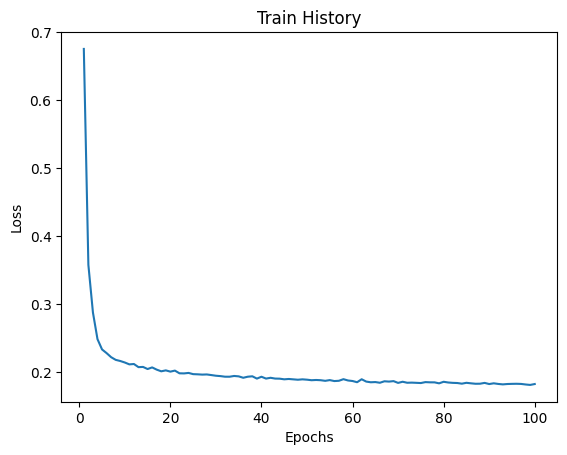

In [12]:
# Train Loss
plt.figure()
plt.plot(range(1, len(train_history)+1), train_history)
plt.title("Train History")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [13]:
# Sample Function
@torch.no_grad()
def sample(model, num_samples, t_0, t_end, ode_solver, device, rtol, atol, shape=(1, 28, 28)):
    model.eval()
    y_0 = torch.randn(num_samples, *shape, device=device)
    # set epsilon for hutchinson trace estimate
    #model.sample_eps(y_0)
    y = odeint(model, y_0, torch.tensor([t_0, t_end], dtype=torch.float32, device=device), rtol=rtol, atol=atol, method=ode_solver)
    y_0, y_1 = y[:,...]
    
    return y_1, y_0

In [14]:
nb_samples = 1000
t_0 = 0
t_1 = 1
ode_solver = "dopri5"
atol = 1e-6
rtol = 1e-6

generated_images , gaussian_noise = sample(model, nb_samples, t_0, t_1, ode_solver, device, rtol=rtol, atol=atol)

# convert to cpu
generated_images_cpu = generated_images.cpu()
gaussian_noise_cpu = gaussian_noise.cpu()

print(generated_images_cpu.shape)
print(generated_images_cpu.shape[0])

print(gaussian_noise_cpu.shape)

torch.Size([1000, 1, 28, 28])
1000
torch.Size([1000, 1, 28, 28])


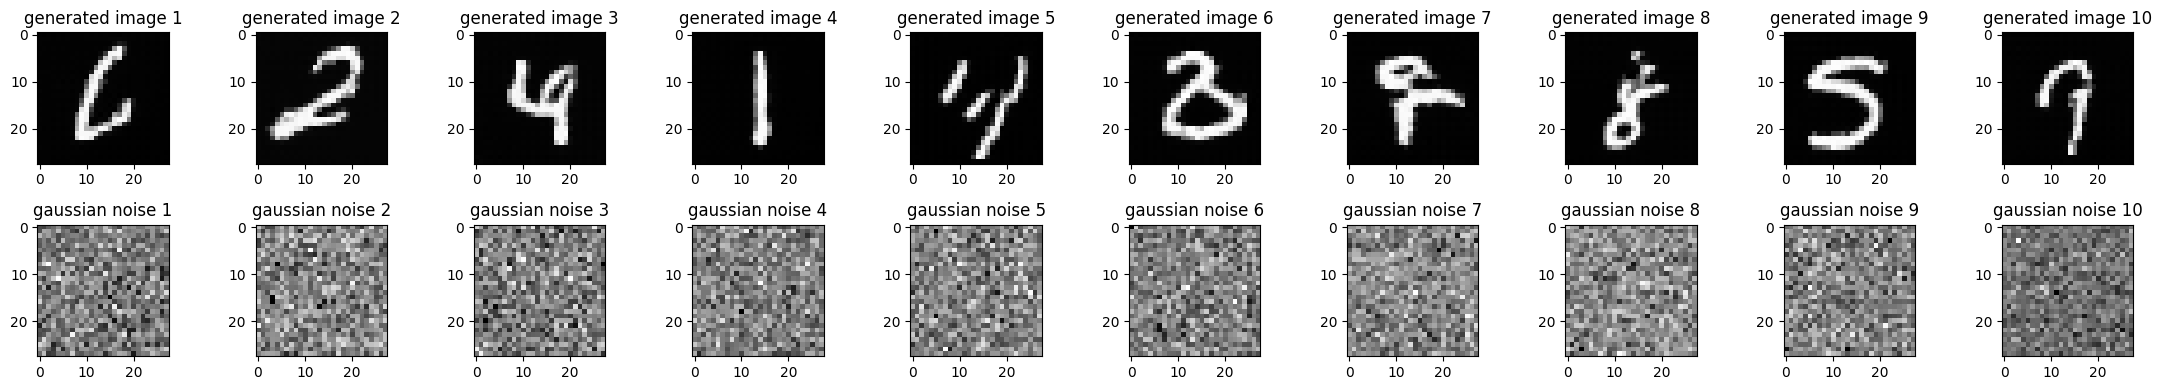

In [15]:
# plot example images
nb_plots = 10

fig, ax = plt.subplots(2, nb_plots, figsize=(2*nb_plots+2, 4))
ax = ax.flatten()
for i in range(0, nb_plots):
    ax[i].imshow(generated_images_cpu[i].squeeze(), cmap="gray")
    ax[i].set_title(f"generated image {i+1}")
    ax[i+nb_plots].imshow(gaussian_noise_cpu[i].squeeze(), cmap="gray")
    ax[i+nb_plots].set_title(f"gaussian noise {i+1}")
fig.tight_layout()


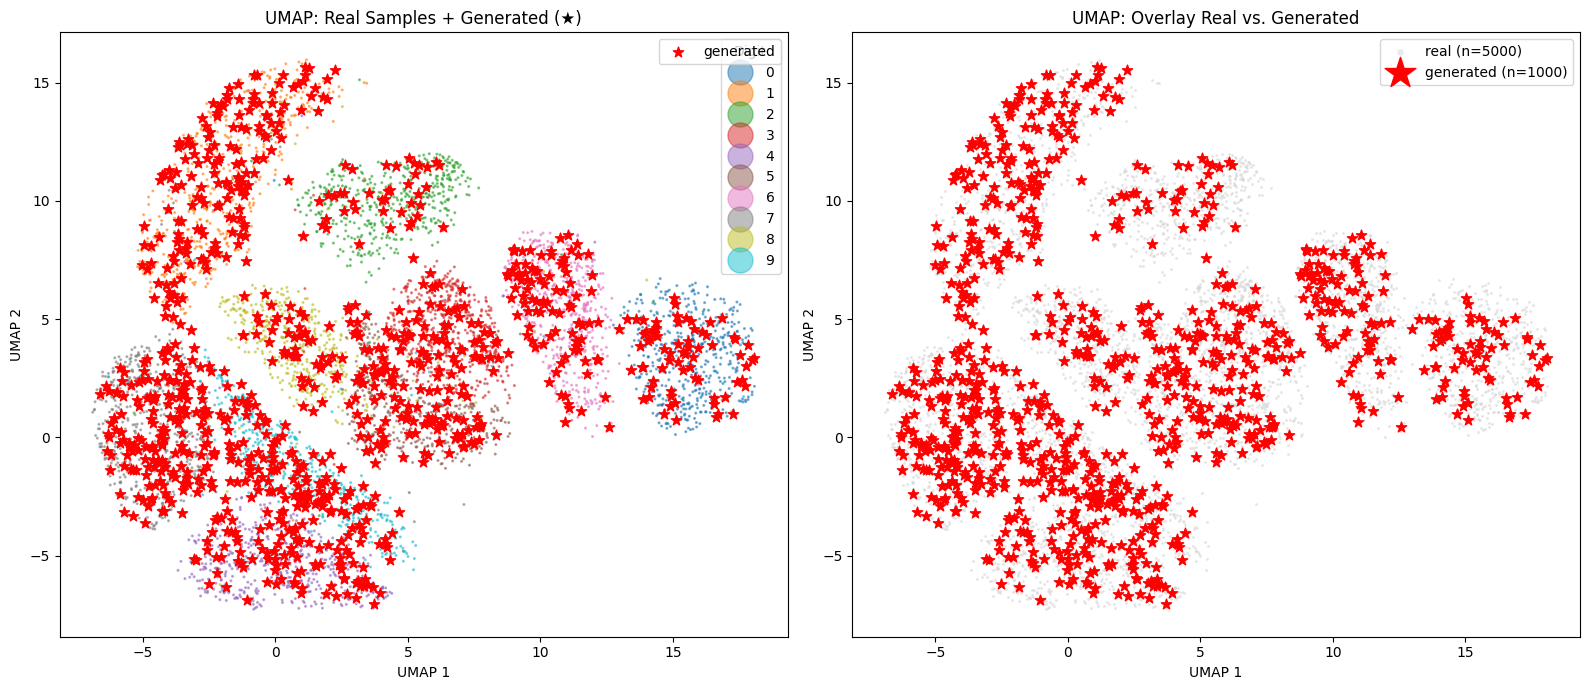

In [16]:
# Umap exploration
# nb of real samples
n_real = 5000

# real flat samples
X_real   = images[:n_real].reshape(n_real, -1).numpy().astype("float32")
L_real   = labels[:n_real].numpy()

# faltten generated data
X_gen = generated_images_cpu.reshape(len(generated_images_cpu), -1).numpy()

# project into learned umap projection
emb_real = reducer.transform(X_real).T
emb_gen  = reducer.transform(X_gen).T  

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# all data
ax = axes[0]
sc = ax.scatter(emb_real[0], emb_real[1], c=L_real, cmap="tab10", s=1.5, alpha=0.5)
legend = ax.legend(*sc.legend_elements(), title="Digit", loc="best", markerscale=3)
ax.add_artist(legend)
ax.scatter(emb_gen[0], emb_gen[1], color="red", s=60, zorder=5, marker="*", label="generated")
ax.legend(loc="upper right")
ax.set_title("UMAP: Real Samples + Generated (★)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# grey overlay
ax = axes[1]
ax.scatter(emb_real[0], emb_real[1], color="lightgrey", s=1.5, alpha=0.4, label=f"real (n={n_real})")
ax.scatter(emb_gen[0], emb_gen[1], color="red", s=60, zorder=5, marker="*", label=f"generated (n={len(X_gen)})")
ax.legend(markerscale=3)
ax.set_title("UMAP: Overlay Real vs. Generated")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

In [17]:
print("gen std over all samples (per pixel, mean):", X_gen.std(axis=0).mean())
print("real std:", X_real.std(axis=0).mean())
print("sample[0] == sample[1]?", np.allclose(X_gen[0], X_gen[1]))

print("real  min/max/mean/std:", X_real.min(), X_real.max(), X_real.mean(), X_real.std())
print("gen   min/max/mean/std:", X_gen.min(),  X_gen.max(),  X_gen.mean(),  X_gen.std())

gen std over all samples (per pixel, mean): 0.34997568
real std: 0.3856896
sample[0] == sample[1]? False
real  min/max/mean/std: -1.0 1.0 -0.73955524 0.61508065
gen   min/max/mean/std: -1.0873296 1.1880031 -0.7830796 0.5579405
